In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(123)

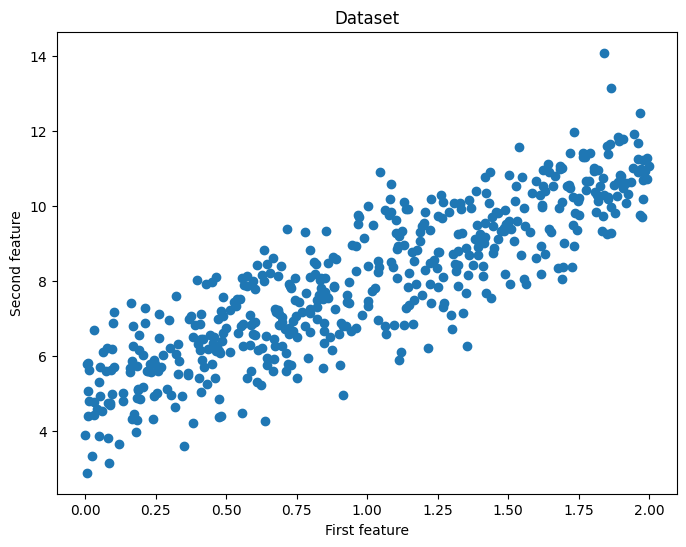

In [ ]:
# We will use a simple training set
X = 2 * np.random.rand(500, 1)
y = 5 + 3 * X + np.random.randn(500, 1)

fig = plt.figure(figsize=(8,6))
plt.scatter(X, y)
plt.title("Dataset")
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

In [ ]:
# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y)

print(f'Shape X_train: {X_train.shape}')
print(f'Shape y_train: {y_train.shape}')
print(f'Shape X_test: {X_test.shape}')
print(f'Shape y_test: {y_test.shape}')

Shape X_train: (375, 1)
Shape y_train: (375, 1)
Shape X_test: (125, 1)
Shape y_test: (125, 1)


## Linear regression class

# **What is Gradient Descent?**

>Gradient descent is an optimization algorithm used in machine learning to minimize the cost function by iteratively adjusting parameters in the direction of the negative gradient, aiming to find the optimal set of parameters.

**The cost function** represents the discrepancy between the predicted output of the model and the actual output. The goal of gradient descent is to find the set of parameters that minimizes this discrepancy and improves the model’s performance.

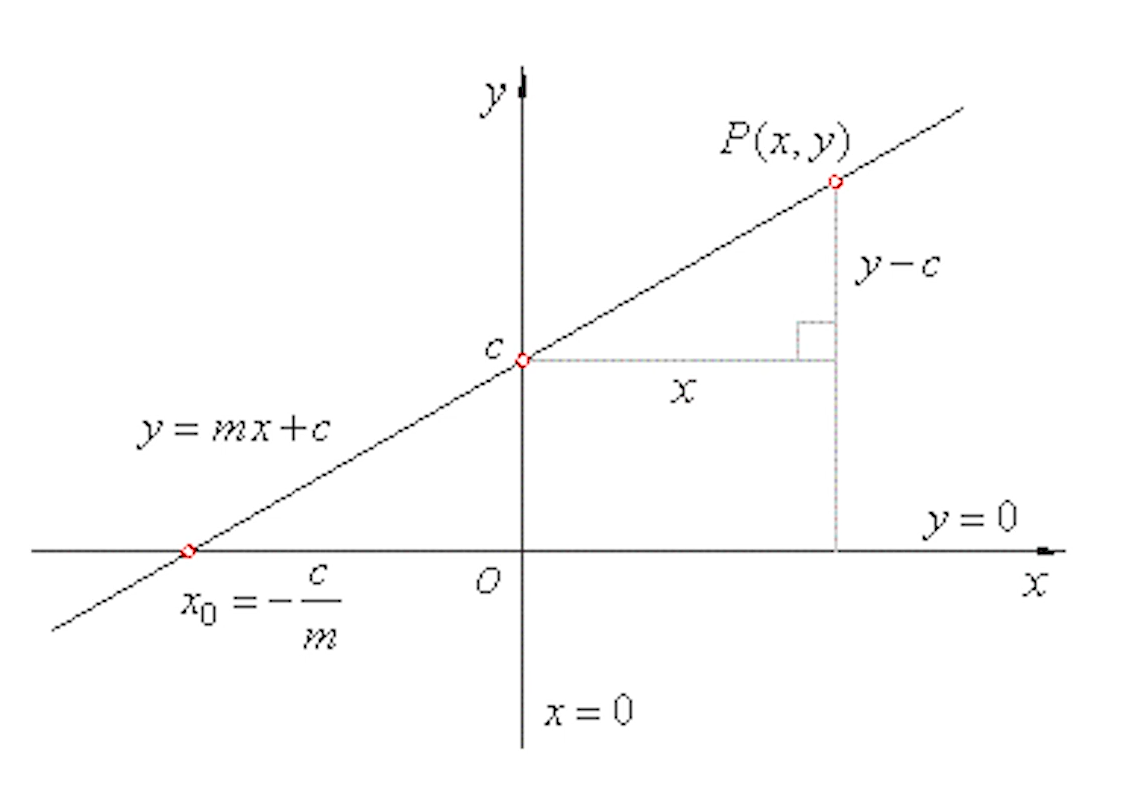

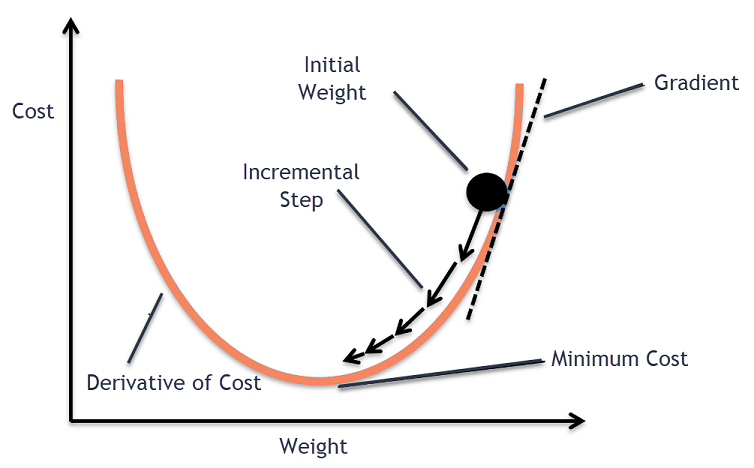

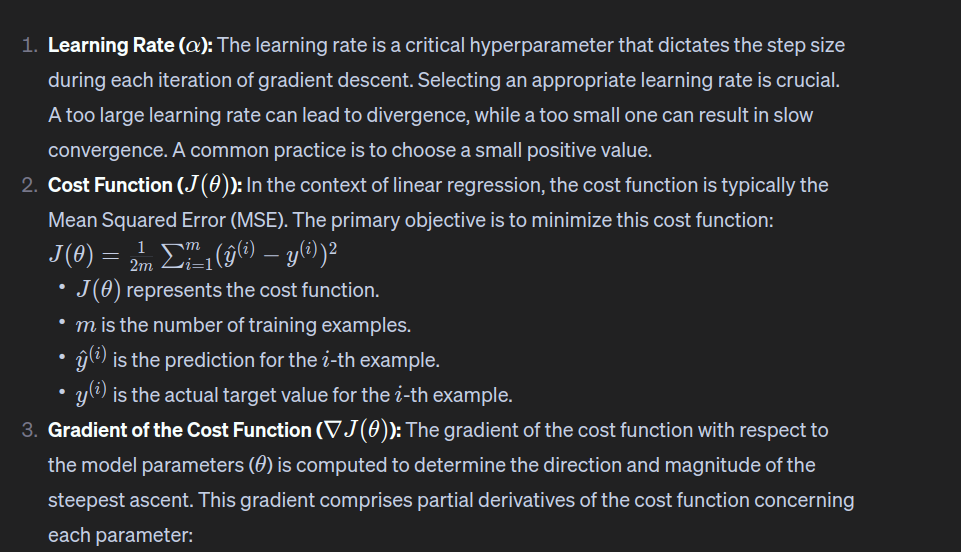

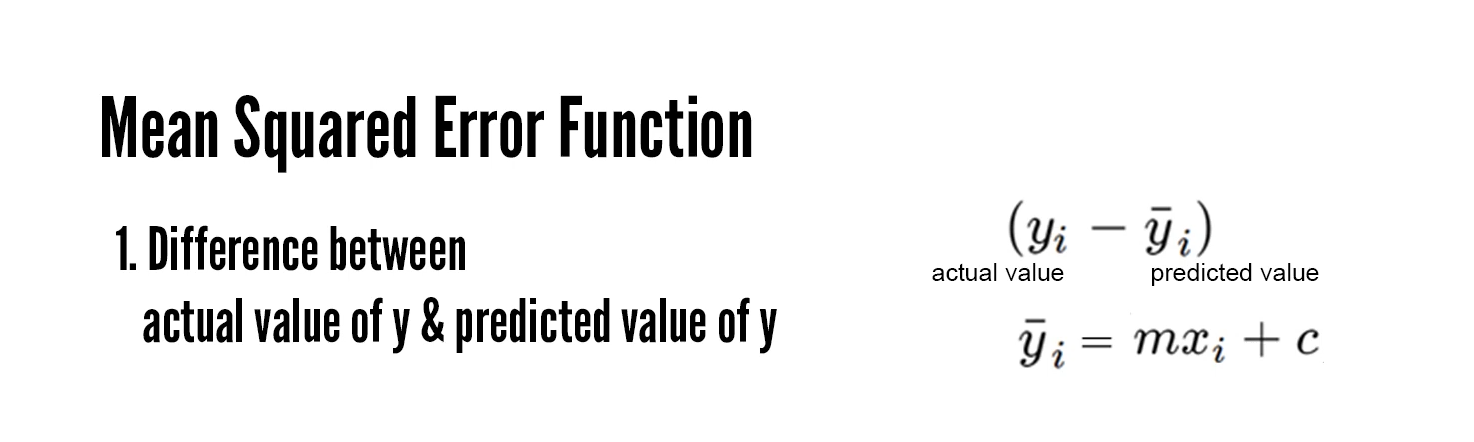

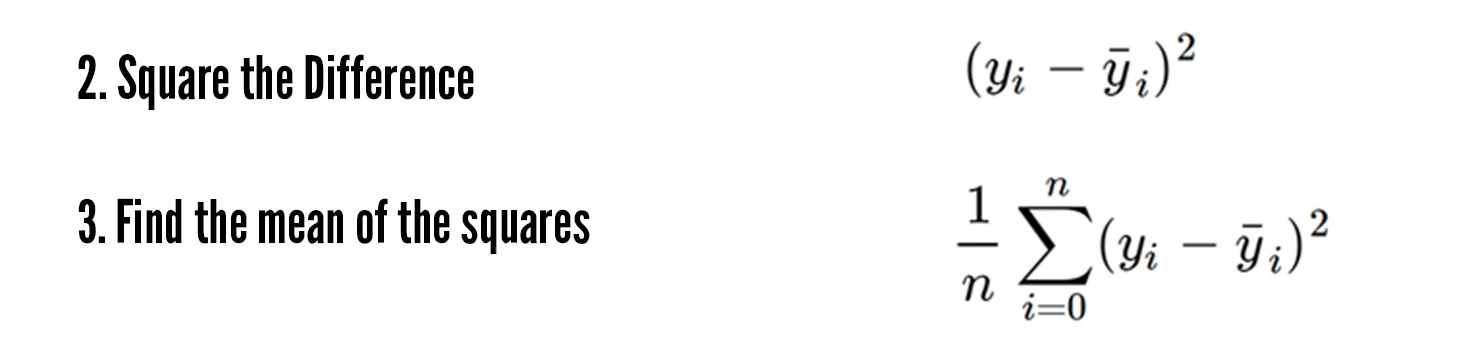

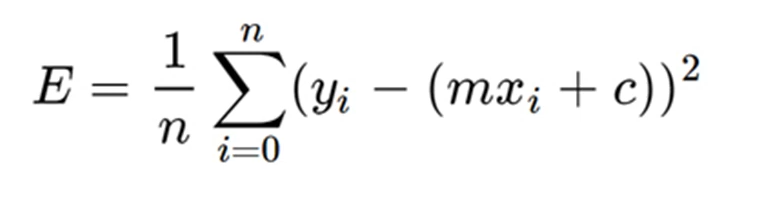

# **What is the Cost Function?**

>The primary set-up for learning neural networks is to define a cost function (also known as a loss function) that measures how well the network predicts outputs on the test set. The goal is to then find a set of weights and biases that minimizes the cost. One common function that is often used is the mean squared error, which measures the difference between the actual value of y and the estimated value of y (the prediction). The equation of the below regression line is hθ(x) = θ + θ1x, which has only two parameters: weight (θ1)and bias (θ0).



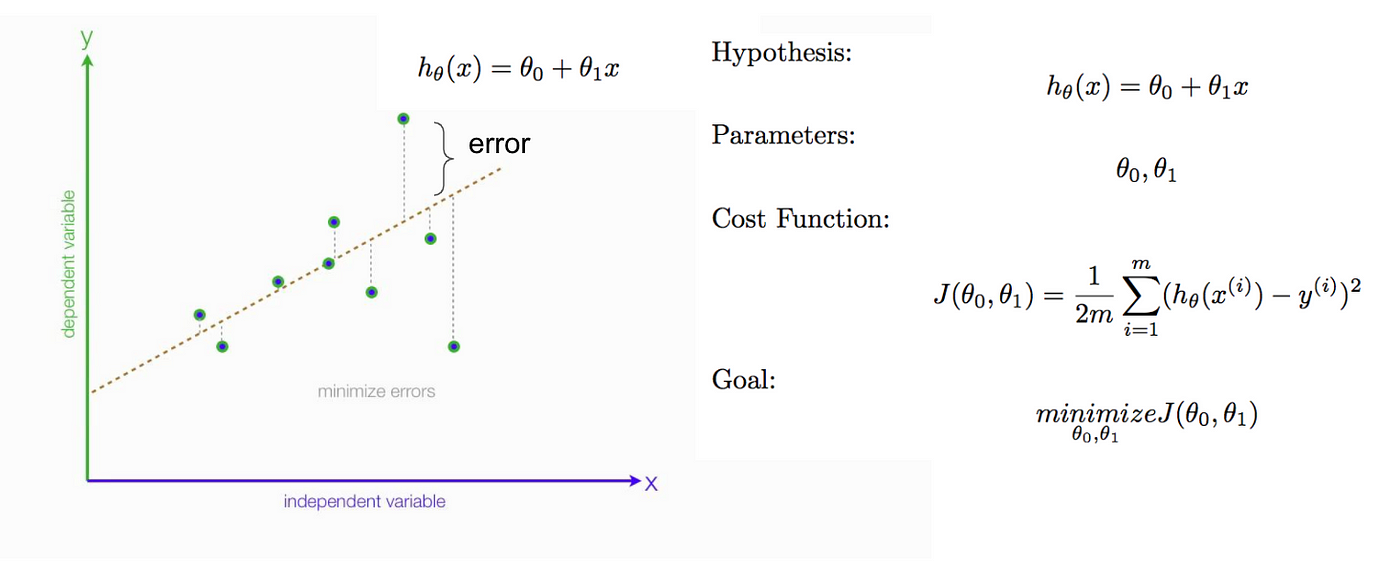

# **How to Minimise the Cost Function**

>>Our goal is to move from the mountain in the top right corner (high cost) to the dark blue sea in the bottom left (low cost). In order to get the lowest error value, we need to adjust the weights ‘θ0’ and ‘θ1’ to reach the smallest possible error. This is because the result of a lower error between the actual and the predicted values means the algorithm has done a good job in learning. Gradient descent is an efficient optimization algorithm that attempts to find a local or global minimum of a function.

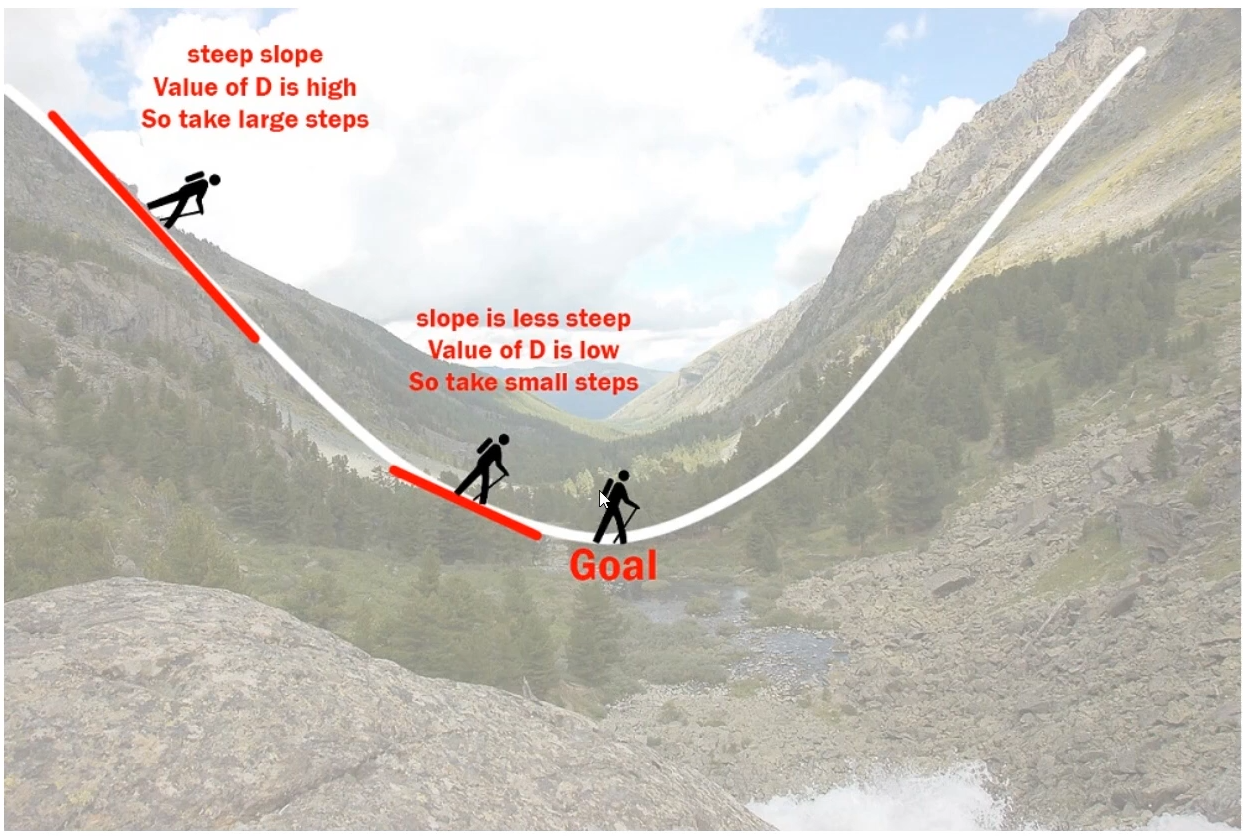

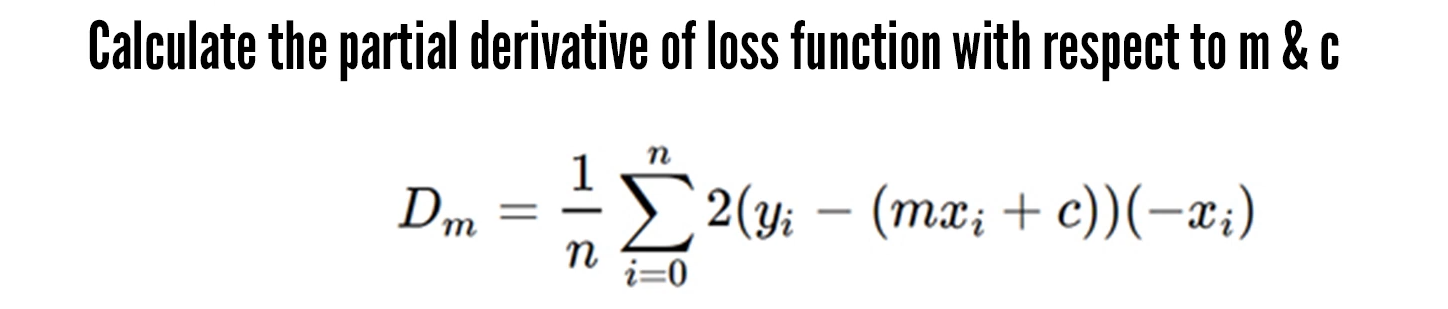

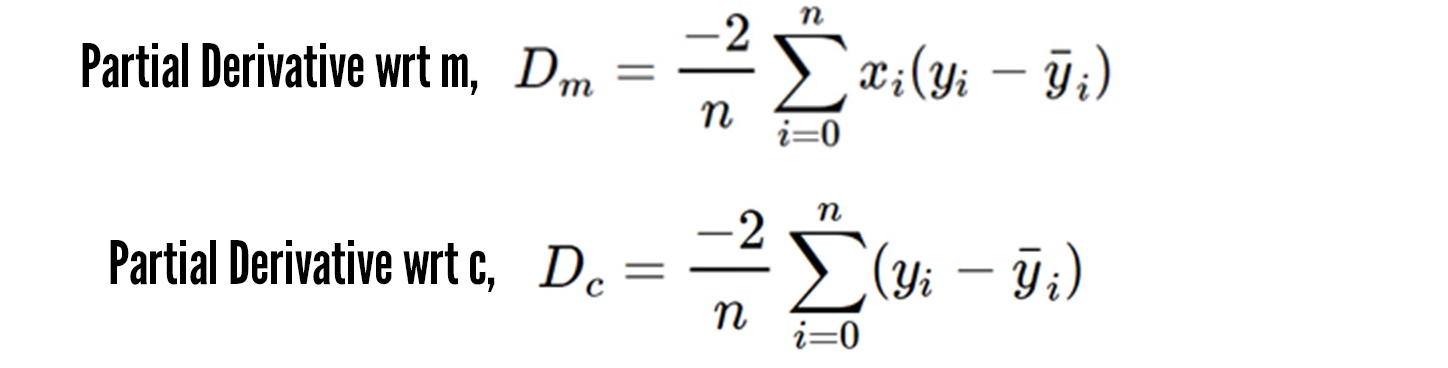

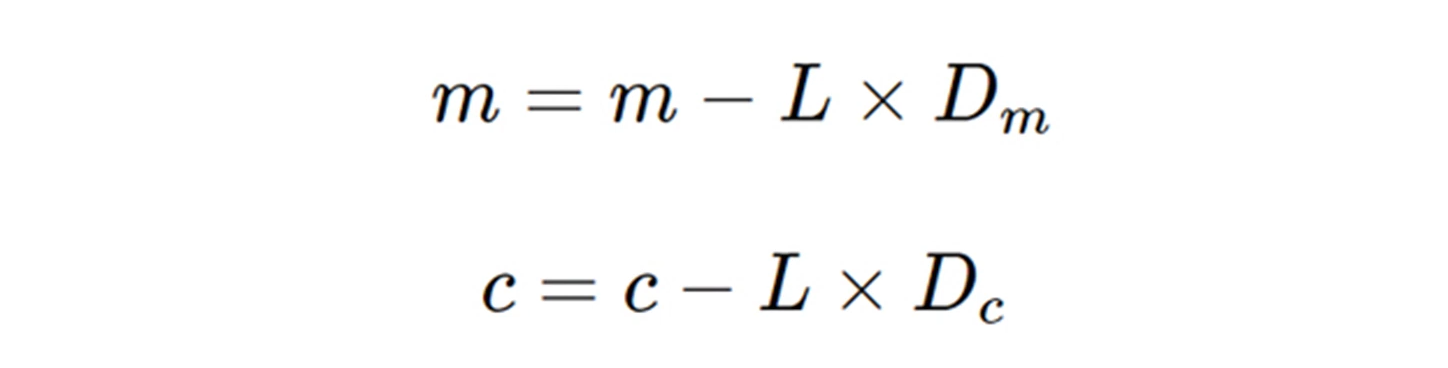

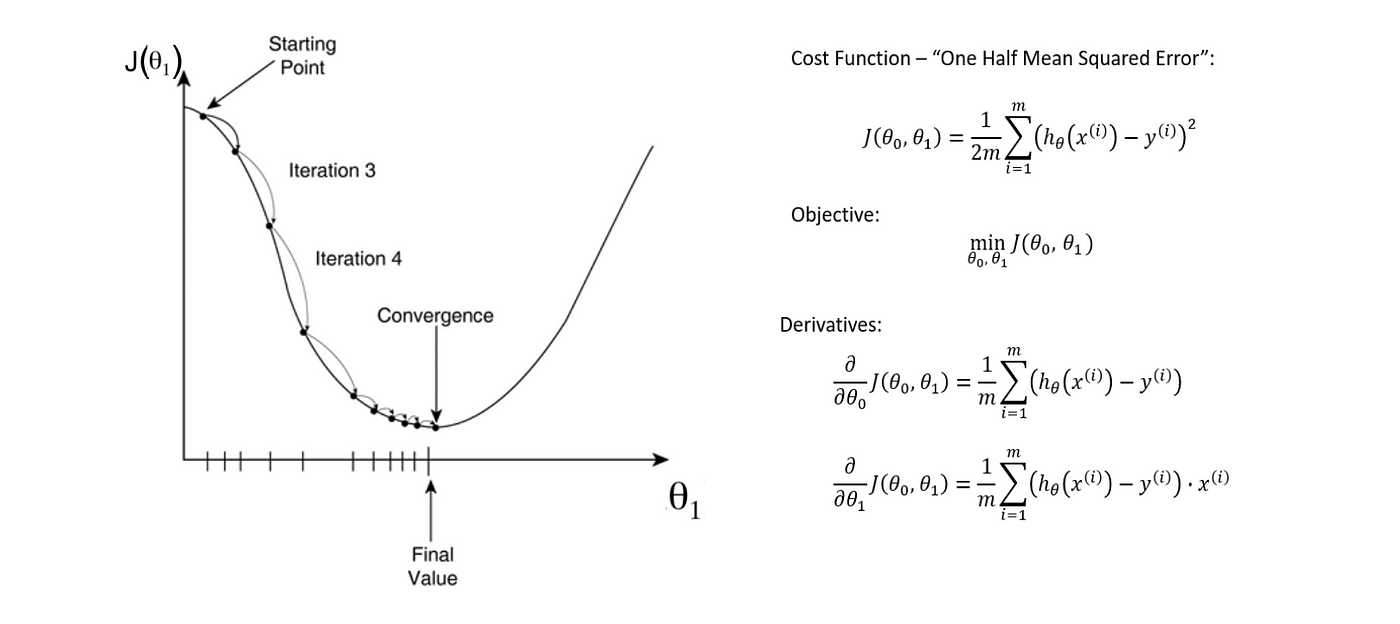

# **Calculating gradient descent**

>*Gradient Descent runs iteratively to find the optimal values of the parameters corresponding to the minimum value of the given cost function, using calculus. Mathematically, the technique of the ‘derivative’ is extremely important to minimise the cost function because it helps get the minimum point. The derivative is a concept from calculus and refers to the slope of the function at a given point. We need to know the slope so that we know the direction (sign) to move the coefficient values in order to get a lower cost on the next iteration.*

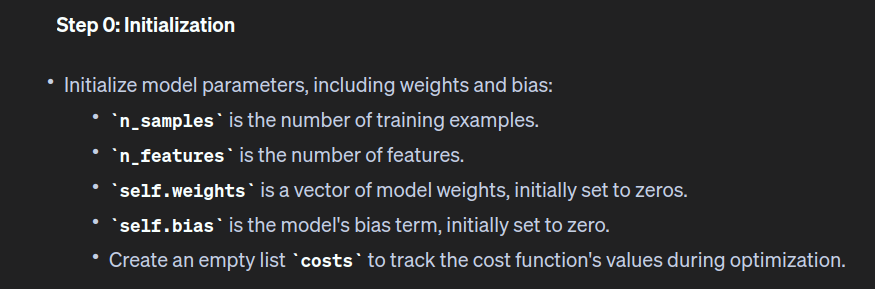

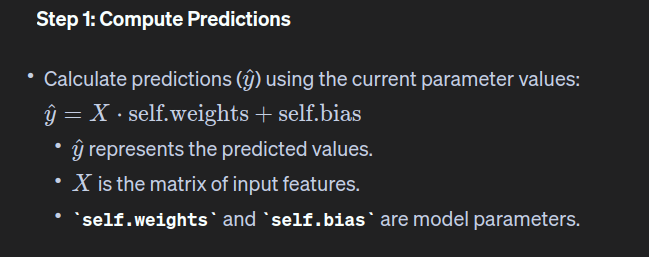

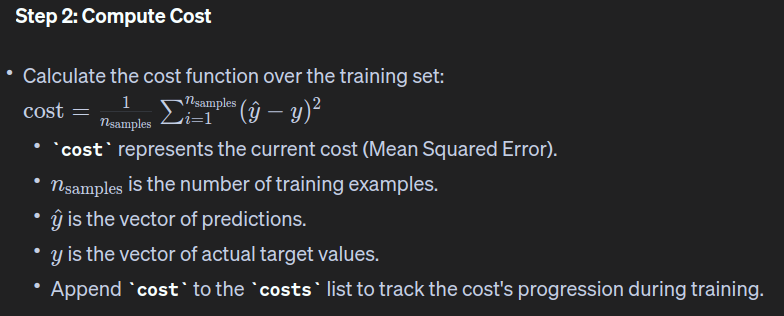

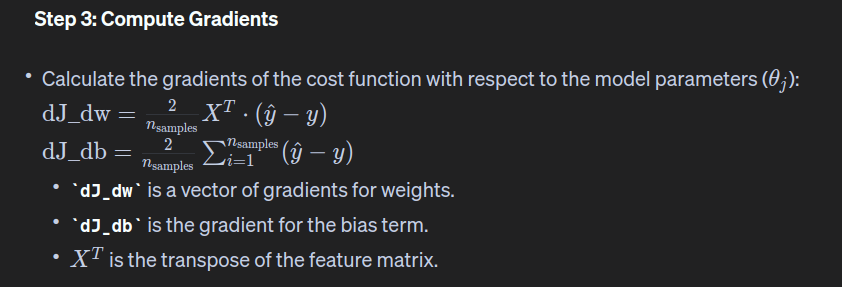

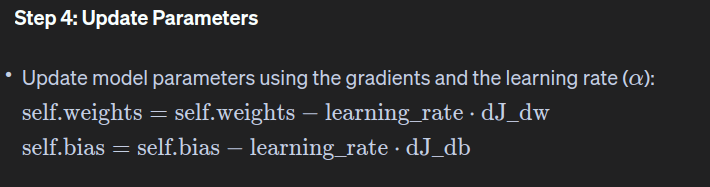

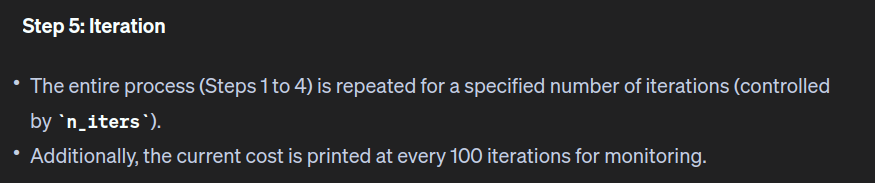

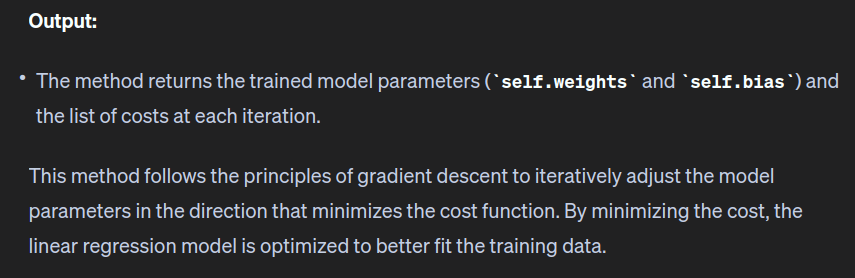

In [ ]:
class LinearRegression:

    def __init__(self):
        pass

    def train_gradient_descent(self, X, y, learning_rate=0.01, n_iters=100):
        """
        Trains a linear regression model using gradient descent
        """
        # Step 0: Initialize the parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(shape=(n_features,1))
        self.bias = 0
        costs = []

        for i in range(n_iters):
            # Step 1: Compute a linear combination of the input features and weights
            y_predict = np.dot(X, self.weights) + self.bias

            # Step 2: Compute cost over training set
            cost = (1 / n_samples) * np.sum((y_predict - y)**2)
            costs.append(cost)

            if i % 100 == 0:
                print(f"Cost at iteration {i}: {cost}")

            # Step 3: Compute the gradients
            dJ_dw = (2 / n_samples) * np.dot(X.T, (y_predict - y))
            dJ_db = (2 / n_samples) * np.sum((y_predict - y))

            # Step 4: Update the parameters
            self.weights = self.weights - learning_rate * dJ_dw
            self.bias = self.bias - learning_rate * dJ_db

        return self.weights, self.bias, costs

    def train_normal_equation(self, X, y):
        """
        Trains a linear regression model using the normal equation
        """
        self.weights = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
        self.bias = 0

        return self.weights, self.bias

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

## Training with gradient descent

Cost at iteration 0: 66.45256981003433
Cost at iteration 100: 2.2084346146095934
Cost at iteration 200: 1.2797812854182806
Cost at iteration 300: 1.2042189195356685
Cost at iteration 400: 1.1564867816573
Cost at iteration 500: 1.121391041394467


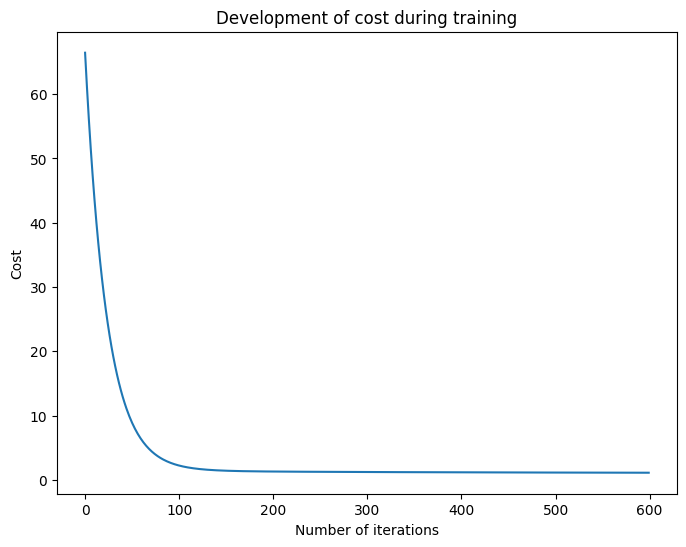

In [ ]:
regressor = LinearRegression()
w_trained, b_trained, costs = regressor.train_gradient_descent(X_train, y_train, learning_rate=0.005, n_iters=600)

fig = plt.figure(figsize=(8,6))
plt.plot(np.arange(600), costs)
plt.title("Development of cost during training")
plt.xlabel("Number of iterations")
plt.ylabel("Cost")
plt.show()

## Testing (gradient descent model)

In [ ]:
n_samples, _ = X_train.shape
n_samples_test, _ = X_test.shape

y_p_train = regressor.predict(X_train)
y_p_test = regressor.predict(X_test)

error_train =  (1 / n_samples) * np.sum((y_p_train - y_train) ** 2)
error_test =  (1 / n_samples_test) * np.sum((y_p_test - y_test) ** 2)

print(f"Error on training set: {np.round(error_train, 4)}")
print(f"Error on test set: {np.round(error_test)}")

Error on training set: 1.0955
Error on test set: 1.0


## Training with normal equation

In [ ]:
# To compute the parameters using the normal equation, we add a bias value of 1 to each input example
X_b_train = np.c_[np.ones((n_samples)), X_train]
X_b_test = np.c_[np.ones((n_samples_test)), X_test]

reg_normal = LinearRegression()
w_trained = reg_normal.train_normal_equation(X_b_train, y_train)

## Testing (normal equation model)

In [ ]:
y_p_train = reg_normal.predict(X_b_train)
y_p_test = reg_normal.predict(X_b_test)

error_train =  (1 / n_samples) * np.sum((y_p_train - y_train) ** 2)
error_test =  (1 / n_samples_test) * np.sum((y_p_test - y_test) ** 2)

print(f"Error on training set: {np.round(error_train, 4)}")
print(f"Error on test set: {np.round(error_test, 4)}")

Error on training set: 1.0228
Error on test set: 1.0432


## Visualize test predictions

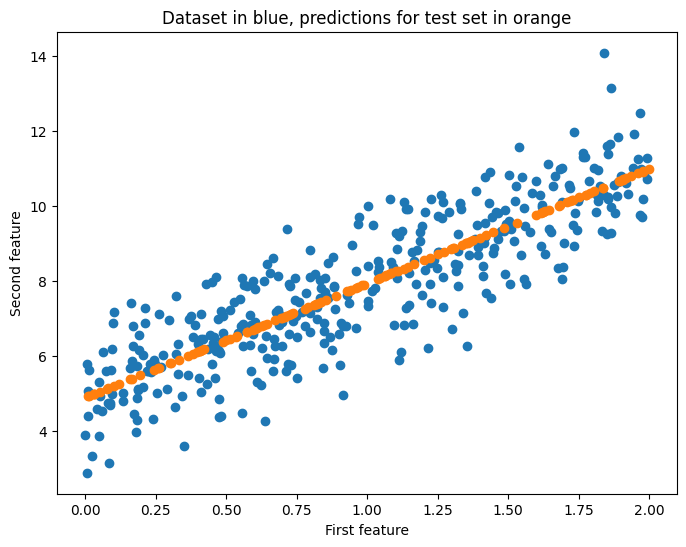

In [ ]:
# Plot the test predictions

fig = plt.figure(figsize=(8,6))
plt.title("Dataset in blue, predictions for test set in orange")
plt.scatter(X_train, y_train)
plt.scatter(X_test, y_p_test)
plt.xlabel("First feature")
plt.ylabel("Second feature")
plt.show()

# **simpleLinearRegression**

### 1. Simple Linear Regression:

**Step 1: Concept**
- **What it is:** Simple linear regression is used to model the relationship between one independent variable (feature) and a single dependent variable (target) when the relationship can be approximated by a straight line.


**Step 2: Application**
- **When to use:** Use simple linear regression when you want to understand and model the linear relationship between a single input factor and the target variable. For example, predicting the relationship between a student's study hours (X) and their exam score (Y).

**Step 3: Practical Implementation**
- **Data Preparation:** Collect data with one input variable and one target variable.
- **Model Training:** Estimate \(\beta_0\) and \(\beta_1\) using techniques like least squares.
- **Evaluation:** Use metrics like Mean Squared Error (MSE) and R-squared to assess model performance.
- **Interpretation:** Analyze the slope (\(\beta_1\)) to understand how the input variable affects the target.

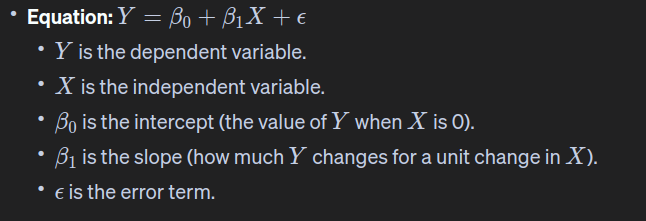

In [ ]:
# Importing the libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Importing the dataset
dataset = pd.read_csv('/content/drive/MyDrive/TUTORIAL_DS/ML/1/1.SimpleLinearRegression/Salary_Data.csv')
print(dataset)

    YearsExperience    Salary
0               1.1   39343.0
1               1.3   46205.0
2               1.5   37731.0
3               2.0   43525.0
4               2.2   39891.0
5               2.9   56642.0
6               3.0   60150.0
7               3.2   54445.0
8               3.2   64445.0
9               3.7   57189.0
10              3.9   63218.0
11              4.0   55794.0
12              4.0   56957.0
13              4.1   57081.0
14              4.5   61111.0
15              4.9   67938.0
16              5.1   66029.0
17              5.3   83088.0
18              5.9   81363.0
19              6.0   93940.0
20              6.8   91738.0
21              7.1   98273.0
22              7.9  101302.0
23              8.2  113812.0
24              8.7  109431.0
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0


In [ ]:
#describe the dataset
dataset.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
#extract input and output features
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

1. `X = dataset.iloc[:, :-1].values`: This line extracts the input features from the dataset. Let me break it down further:
   - `dataset.iloc[:, :-1]`: The `iloc` method is used to select rows and columns from the dataset. Here, `:` represents selecting all rows, and `:-1` represents selecting all columns except the last one. So, this part of the code selects all rows and all columns except the last one.
   - `.values`: The `.values` attribute is used to extract the selected data as a NumPy array. This is often done because machine learning libraries like scikit-learn generally expect data to be in NumPy array format.

2. `y = dataset.iloc[:, 1].values`: This line extracts the output feature (target variable) from the dataset. Here's the breakdown:
   - `dataset.iloc[:, 1]`: Similarly, it uses `iloc` to select all rows and only the second column (index 1). The second column is often where the target variable or output feature is located.
   - `.values`: Again, this is used to convert the selected data into a NumPy array.

In summary, the code separates the dataset into two variables:
- `X`, which contains the input features (independent variables) as a NumPy array.
- `y`, which contains the output feature (dependent variable or target variable) as a NumPy array.


In [ ]:
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [ ]:
y

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

In [ ]:
# Import from the correct module
from sklearn.model_selection import train_test_split

# Your code for splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)


In [ ]:
X_train.shape

(20, 1)

In [ ]:
y_train.shape

(20,)

In [ ]:
X_test.shape

(10, 1)

In [ ]:
y_test.shape

(10,)

In [ ]:
#fitting simple linear regression to the training set
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [ ]:
#fit the regressor
regressor.fit(X_train,y_train)

LinearRegression()

In [ ]:
#predictig test results
y_pred=regressor.predict(X_test)

In [ ]:
y_pred

array([ 40835.10590871, 123079.39940819,  65134.55626083,  63265.36777221,
       115602.64545369, 108125.8914992 , 116537.23969801,  64199.96201652,
        76349.68719258, 100649.1375447 ])

In [ ]:
y_test

array([ 37731., 122391.,  57081.,  63218., 116969., 109431., 112635.,
        55794.,  83088., 101302.])

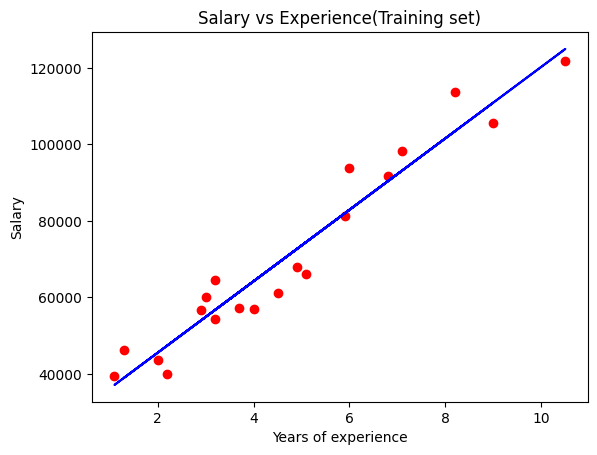

In [ ]:
#visualising training set results
plt.scatter(X_train,y_train,color='red')
plt.plot(X_train,regressor.predict(X_train),color='blue')
plt.title('Salary vs Experience(Training set)')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()

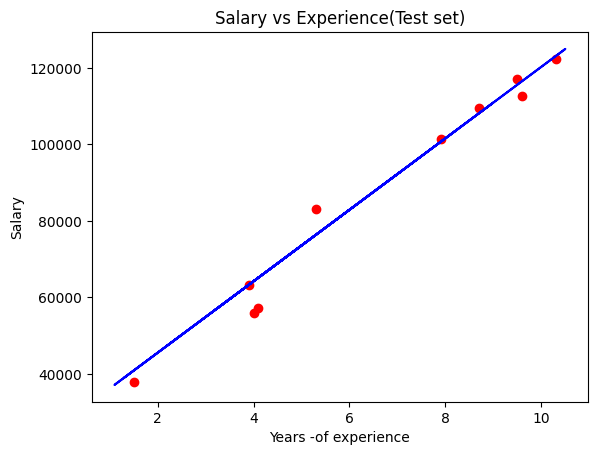

In [ ]:
#visualising test set results
plt.scatter(X_test,y_test,color='red')
plt.plot(X_train,regressor.predict(X_train),color='blue')
plt.title('Salary vs Experience(Test set)')
plt.xlabel('Years -of experience')
plt.ylabel('Salary')
plt.show()